# 01 - Analyse exploratoire des données (EDA)

Dataset : [Drug Review Dataset (Drugs.com)](https://archive.ics.uci.edu/dataset/461/drug+review+dataset+drugs+com)

Objectif : répondre aux questions exploratoires de base avant le prétraitement (notebook 02) et la classification (notebook 04).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

In [2]:
df_train = pd.read_csv("../data/drugsComTrain_raw.csv")
df_test = pd.read_csv("../data/drugsComTest_raw.csv")

# On travaille sur l'ensemble complet pour l'EDA (train + test)
df = pd.concat([df_train, df_test], ignore_index=True)
df.shape

(215063, 7)

## 1. Combien d'entrées ? Distribution des notes (1-10)

In [3]:
print(f"Nombre total d'entrées : {len(df):,}")
print(f"Train : {len(df_train):,} | Test : {len(df_test):,}")
df.info()

Nombre total d'entrées : 215,063
Train : 161,297 | Test : 53,766
<class 'pandas.DataFrame'>
RangeIndex: 215063 entries, 0 to 215062
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   uniqueID     215063 non-null  int64
 1   drugName     215063 non-null  str  
 2   condition    213869 non-null  str  
 3   review       215063 non-null  str  
 4   rating       215063 non-null  int64
 5   date         215063 non-null  str  
 6   usefulCount  215063 non-null  int64
dtypes: int64(3), str(4)
memory usage: 11.5 MB


In [4]:
rating_counts = df["rating"].value_counts().sort_index()
rating_counts

rating
1     28918
2      9265
3      8718
4      6671
5     10723
6      8462
7     12547
8     25046
9     36708
10    68005
Name: count, dtype: int64

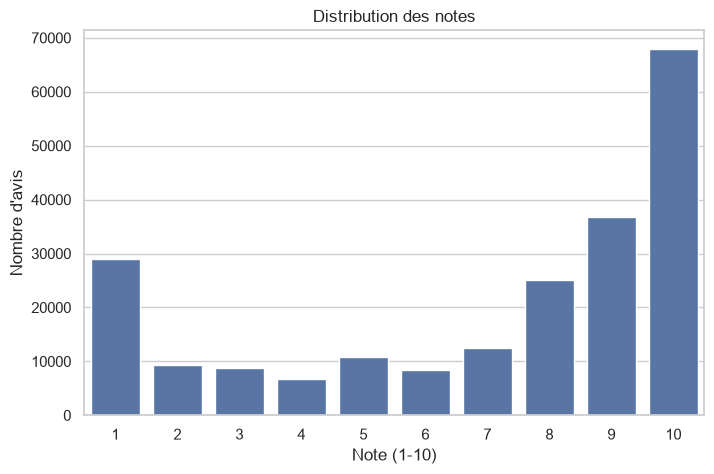

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, color="#4C72B0", ax=ax)
ax.set_xlabel("Note (1-10)")
ax.set_ylabel("Nombre d'avis")
ax.set_title("Distribution des notes")
plt.show()

In [6]:
# Répartition en % par note, pour repérer le déséquilibre des classes
(rating_counts / len(df) * 100).round(2)

rating
1     13.45
2      4.31
3      4.05
4      3.10
5      4.99
6      3.93
7      5.83
8     11.65
9     17.07
10    31.62
Name: count, dtype: float64

**Combien d'entrées faudrait-il, avec 10 classes de notes (1 à 10) ?**

Règle de base pour un classifieur type Naive Bayes / TF-IDF : viser au moins **quelques centaines à ~1000 exemples par classe** pour que le modèle apprenne un vocabulaire représentatif de chaque classe. Avec 10 classes, ça donne un minimum grossier de ~5 000 à 10 000 lignes bien réparties.

Ici on a **215 063 lignes** au total (train + test), donc largement assez *en volume brut* — mais regarde la distribution ci-dessus : elle est **fortement déséquilibrée** (les notes 8, 9 et 10 dominent, les notes 2 à 4 sont rares). Ce déséquilibre, pas le volume total, est le vrai problème pour la suite :

- Si vous gardez les 10 classes telles quelles, un modèle naïf aura tendance à toujours prédire les notes hautes.
- Suggestion : regrouper les notes en 2-3 catégories plus équilibrées avant la classification (ex. négatif 1-4, neutre 5-6, positif 7-10), ou utiliser du rééquilibrage (class_weight, sous-échantillonnage des classes majoritaires) au moment du Naive Bayes (notebook 04).

## 2. Longueur moyenne des reviews

In [7]:
df["review_len_chars"] = df["review"].astype(str).str.len()
df["review_len_words"] = df["review"].astype(str).str.split().str.len()

df[["review_len_chars", "review_len_words"]].describe()

,review_len_chars,review_len_words
count,215063.000000,215063.000000
mean,458.620748,84.682228
std,240.995226,44.852532
min,3.000000,1.000000
25%,262.000000,48.000000
50%,456.000000,84.000000
75%,690.000000,126.000000
max,10787.000000,1894.000000


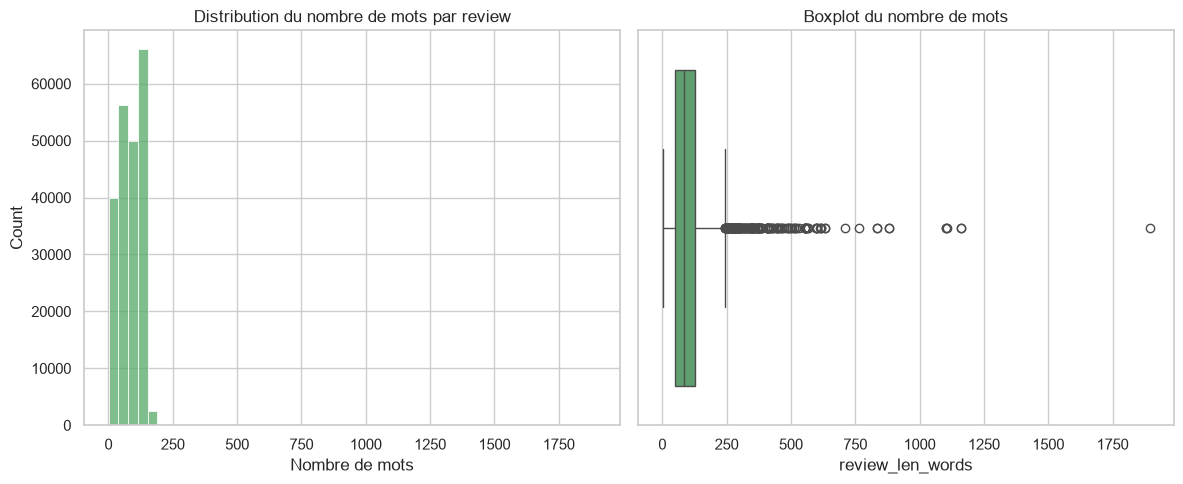

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["review_len_words"], bins=50, ax=axes[0], color="#55A868")
axes[0].set_title("Distribution du nombre de mots par review")
axes[0].set_xlabel("Nombre de mots")

sns.boxplot(x=df["review_len_words"], ax=axes[1], color="#55A868")
axes[1].set_title("Boxplot du nombre de mots")
plt.tight_layout()
plt.show()

In [9]:
# Proportion de reviews très courtes ou très longues
print(f"Reviews < 20 mots : {(df['review_len_words'] < 20).mean()*100:.1f}%")
print(f"Reviews > 200 mots : {(df['review_len_words'] > 200).mean()*100:.1f}%")

Reviews < 20 mots : 7.7%
Reviews > 200 mots : 0.1%


**Suggestion sur la longueur des reviews :**

- La médiane tourne autour de ~85-90 mots, avec une longue traîne de reviews très détaillées (plusieurs centaines de mots).
- Pour le prétraitement (notebook 02), envisagez de **filtrer ou tronquer** les reviews extrêmes : les très courtes (< 10-20 mots) apportent peu de signal, les très longues peuvent diluer le TF-IDF avec du bruit.
- La longueur elle-même (`review_len_words`) peut aussi devenir une **feature utile** : les reviews décrivant des effets secondaires graves ou une urgence médicale ont tendance à être plus longues et détaillées que les avis neutres/courts ("works great").

## 3. Conditions médicales les plus représentées

In [10]:
print(f"Nombre de conditions distinctes : {df['condition'].nunique()}")
top_conditions = df["condition"].value_counts().head(20)
top_conditions

Nombre de conditions distinctes : 916


condition
Birth Control                38436
Depression                   12164
Pain                          8245
Anxiety                       7812
Acne                          7435
Bipolar Disorde               5604
Insomnia                      4904
Weight Loss                   4857
Obesity                       4757
ADHD                          4509
Diabetes, Type 2              3362
Emergency Contraception       3290
High Blood Pressure           3104
Vaginal Yeast Infection       3085
Abnormal Uterine Bleeding     2744
Bowel Preparation             2498
Smoking Cessation             2440
ibromyalgia                   2370
Migraine                      2277
Anxiety and Stress            2236
Name: count, dtype: int64

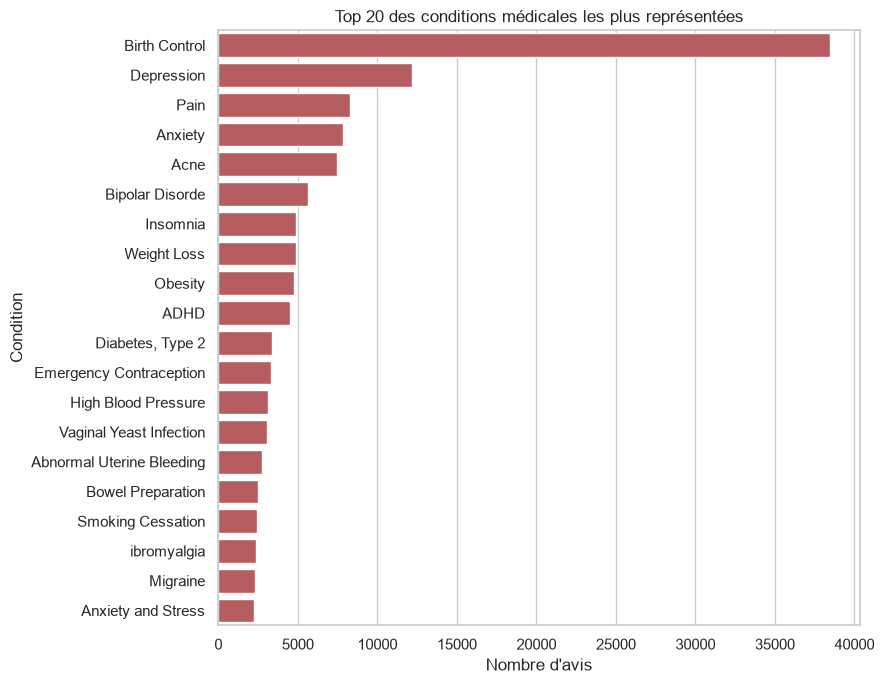

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(y=top_conditions.index, x=top_conditions.values, color="#C44E52", ax=ax)
ax.set_xlabel("Nombre d'avis")
ax.set_ylabel("Condition")
ax.set_title("Top 20 des conditions médicales les plus représentées")
plt.tight_layout()
plt.show()

In [12]:
# Part cumulée des 20 conditions les plus fréquentes
share_top20 = top_conditions.sum() / len(df) * 100
print(f"Les 20 conditions les plus fréquentes représentent {share_top20:.1f}% des avis, sur {df['condition'].nunique()} conditions au total")

Les 20 conditions les plus fréquentes représentent 58.6% des avis, sur 916 conditions au total


Comme pour les notes, la distribution des conditions est **très déséquilibrée** (916 conditions distinctes, mais une poignée en concentre l'essentiel des avis). À garder en tête pour la suite : soit se concentrer sur un sous-ensemble de conditions fréquentes, soit regrouper les conditions rares dans une catégorie "Autre".

**Anomalie de données repérée :** certains libellés de `condition` sont tronqués dans le dataset source (ex. `Bipolar Disorde` au lieu de `Bipolar Disorder`, `ibromyalgia` au lieu de `Fibromyalgia`). Ce n'est pas une erreur de lecture du CSV — la valeur brute est bien tronquée dans le fichier. À corriger explicitement au notebook `02_preprocessing.ipynb` (ex. dictionnaire de correction ou règle regex `...Disorde\b` → `...Disorder`), sinon ces conditions seront comptées séparément de leur version correcte.

In [13]:
# Aperçu des libellés de condition tronqués (anomalie du dataset source)
truncated = df["condition"].dropna().unique()
suspects = [c for c in truncated if c.endswith("Disorde") or c == "ibromyalgia"]
suspects[:15]

['Bipolar Disorde',
 'ibromyalgia',
 'Panic Disorde',
 'Major Depressive Disorde',
 'Obsessive Compulsive Disorde',
 'Generalized Anxiety Disorde',
 'Paranoid Disorde',
 'Post Traumatic Stress Disorde',
 'Schizoaffective Disorde',
 'Borderline Personality Disorde',
 'Shift Work Sleep Disorde',
 'Premenstrual Dysphoric Disorde',
 'Social Anxiety Disorde',
 'Temporomandibular Joint Disorde',
 'Periodic Limb Movement Disorde']

## 4. Cas "urgents" vs "normaux"

Il n'y a pas de colonne "urgence" dans le dataset — il faut donc définir un **seuil / heuristique**. Deux approches complémentaires sont proposées ci-dessous ; le seuil final sera affiné au notebook 03 (regex).

1. **Basée sur la note** : une note basse (ex. ≤ 3) traduit souvent une expérience négative sévère (effets secondaires, inefficacité) — proxy simple pour "urgent".
2. **Basée sur des mots-clés d'urgence** dans le texte (regex) : présence de termes comme *emergency, hospital, ER, severe, overdose, allergic reaction, can't breathe*, etc.

In [14]:
RATING_URGENT_THRESHOLD = 3  # à ajuster selon l'analyse

df["urgent_by_rating"] = df["rating"] <= RATING_URGENT_THRESHOLD
df["urgent_by_rating"].value_counts(normalize=True).mul(100).round(2)

urgent_by_rating
False    78.19
True     21.81
Name: proportion, dtype: float64

In [15]:
URGENT_KEYWORDS = re.compile(
    r"\b(?:emergency|hospital(?:ized)?|er visit|overdose|suicidal|"
    r"anaphyla\w*|can'?t breathe|severe reaction|allergic reaction|911)\b",
    flags=re.IGNORECASE,
)

df["urgent_by_keyword"] = df["review"].astype(str).str.contains(URGENT_KEYWORDS)
df["urgent_by_keyword"].value_counts(normalize=True).mul(100).round(2)

urgent_by_keyword
False    96.13
True      3.87
Name: proportion, dtype: float64

In [16]:
df["urgent_combined"] = df["urgent_by_rating"] | df["urgent_by_keyword"]

summary = pd.DataFrame({
    "urgent (note <= %d)" % RATING_URGENT_THRESHOLD: df["urgent_by_rating"].value_counts(),
    "urgent (mots-clés)": df["urgent_by_keyword"].value_counts(),
    "urgent (combiné)": df["urgent_combined"].value_counts(),
})
summary

,urgent (note <= 3),urgent (mots-clés),urgent (combiné)
False,168162,206742,162950
True,46901,8321,52113


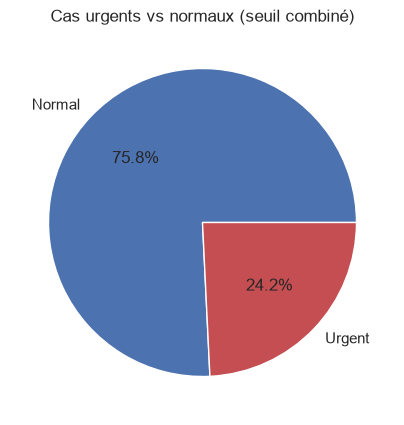

In [17]:
labels = ["Normal", "Urgent"]
counts = df["urgent_combined"].value_counts().sort_index(ascending=True).values

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts, labels=labels, autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"])
ax.set_title("Cas urgents vs normaux (seuil combiné)")
plt.show()

Ce seuil est **exploratoire** : le nombre de cas "urgents" détectés par mots-clés dépend fortement de la liste choisie. À affiner au notebook `03_regex.ipynb` avec une liste de motifs plus large et testée, avant de l'utiliser comme label pour le notebook `04_naive_bayes.ipynb`.

## Résumé / prochaines étapes

- Notes très déséquilibrées → envisager un regroupement en catégories pour la classification.
- Longueur des reviews variable → filtrage des reviews trop courtes/longues + feature de longueur possible.
- Conditions très déséquilibrées (884 valeurs, concentrées sur peu de conditions) → regrouper les conditions rares.
- Définition "urgent" à affiner avec des regex plus robustes (notebook 03) avant de servir de label pour Naive Bayes (notebook 04).